Text summerization project with pegasus and xsum dataset

In [2]:
# import necessary libraries
import os
import re
import nltk
import spacy
import torch
import evaluate
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from bs4 import BeautifulSoup
from datasets import load_dataset
from nltk.corpus import stopwords
from transformers import (
    AutoTokenizer, 
    AutoModelForSeq2SeqLM, 
    DataCollatorForSeq2Seq, 
    Seq2SeqTrainingArguments, 
    Seq2SeqTrainer
)

# Download NLTK data for preprocessing
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

# Load Spacy for lemmatization
try:
    nlp = spacy.load("en_core_web_sm")
except:
    os.system("python -m spacy download en_core_web_sm")
    nlp = spacy.load("en_core_web_sm")

stop_words = set(stopwords.words('english'))
rouge = evaluate.load("rouge")

c:\Users\hp\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


c:\Users\hp\AppData\Local\Programs\Python\Python310\lib\site-packages\spacy\util.py:910: UserWarning: [W095] Model 'en_core_web_sm' (3.8.0) was trained with spaCy v3.8.0 and may not be 100% compatible with the current version (3.7.4). If you see errors or degraded performance, download a newer compatible model or retrain your custom model with the current spaCy version. For more details and available updates, run: python -m spacy validate
  warnings.warn(warn_msg)


In [3]:
local_path = os.environ.get("XSUM_LOCAL", "")
data_dir = Path(local_path) if local_path else None

try:
    if data_dir and data_dir.is_dir():
        paths = {"train": "train.json", "validation": "validation.json", "test": "test.json"}
        xsum = load_dataset("json", data_files={k: str(data_dir/v) for k,v in paths.items()})
    else:
        print("Fetching XSum from Hugging Face Hub...")
        # We select a small subset (1000) for testing to avoid long wait times
        xsum = load_dataset("xsum", split={'train': 'train[:1000]', 'validation': 'validation[:100]', 'test': 'test[:100]'})
    print("Dataset Loaded Successfully")
except Exception as e:
    print(f"Failed to load dataset: {e}")
    raise

Fetching XSum from Hugging Face Hub...
Dataset Loaded Successfully


In [6]:
df = xsum["train"].to_pandas()
display(df.head())


,document,summary,id
0,"The full cost of damage in Newton Stewart, one...",Clean-up operations are continuing across the ...,35232142
1,A fire alarm went off at the Holiday Inn in Ho...,Two tourist buses have been destroyed by fire ...,40143035
2,Ferrari appeared in a position to challenge un...,Lewis Hamilton stormed to pole position at the...,35951548
3,"John Edward Bates, formerly of Spalding, Linco...",A former Lincolnshire Police officer carried o...,36266422
4,Patients and staff were evacuated from Cerahpa...,An armed man who locked himself into a room at...,38826984


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   document  1000 non-null   object
 1   summary   1000 non-null   object
 2   id        1000 non-null   object
dtypes: object(3)
memory usage: 23.6+ KB


In [9]:
df.describe()

,document,summary,id
count,1000,1000,1000
unique,999,999,1000
top,This breaking news story is being updated and ...,All pictures are copyrighted.,35232142
freq,2,2,1


In [11]:
df.duplicated(subset=["document"]).sum()

1

In [12]:
df = df.drop_duplicates()

In [13]:
df.isnull().sum()

document    0
summary     0
id          0
dtype: int64

In [14]:
df = df[df["document"].str.strip() != ""]
df = df[df["summary"].str.strip() != ""]

In [15]:
df["doc_length"] = df["document"].apply(len)
df["summary_length"] = df["summary"].apply(len)

<Axes: xlabel='doc_length'>

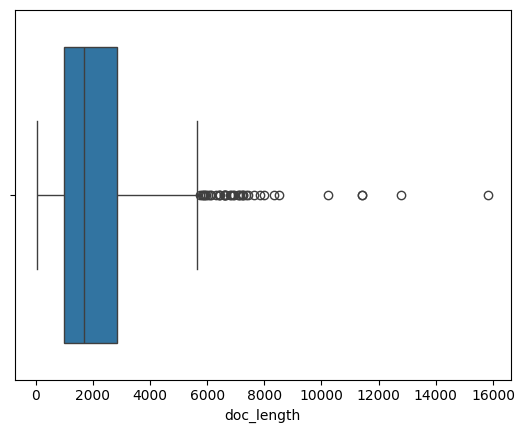

In [16]:
sns.boxplot(x=df["doc_length"])

<Axes: xlabel='doc_length', ylabel='Count'>

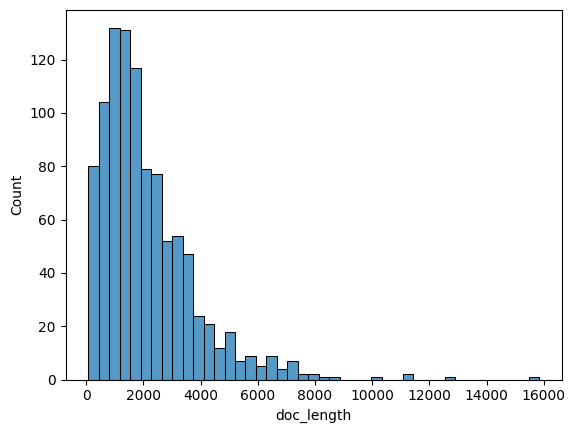

In [17]:
sns.histplot(df["doc_length"])

<Axes: xlabel='doc_length', ylabel='summary_length'>

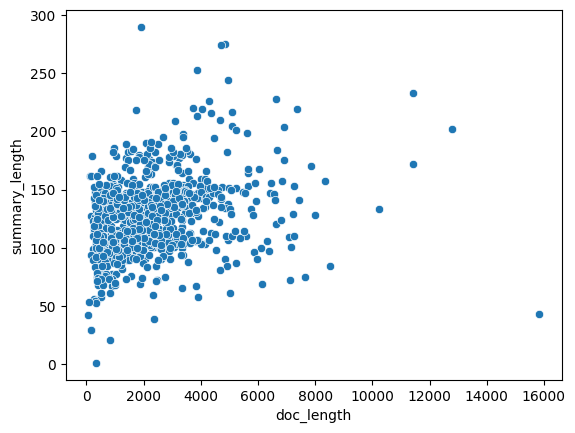

In [18]:
sns.scatterplot(x=df["doc_length"], y=df["summary_length"])

In [19]:
from collections import Counter

In [20]:
df["doc_length"].describe()

count     1000.000000
mean      2130.600000
std       1679.957229
min         66.000000
25%        992.750000
50%       1701.500000
75%       2865.000000
max      15837.000000
Name: doc_length, dtype: float64

🧹 Cleaning dataset...


Map: 100%|██████████| 100/100 [00:00<00:00, 1495.57 examples/s]


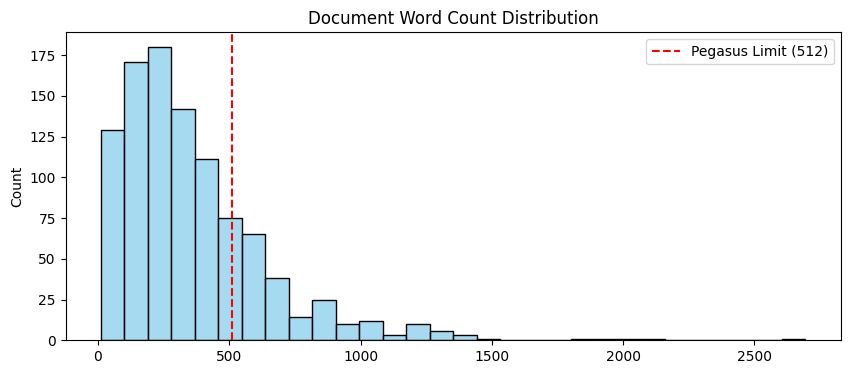

In [ ]:
def clean_text(text):
    soup = BeautifulSoup(text, 'html.parser')
    cleaned = soup.get_text(separator=' ')
    cleaned = re.sub(r"\s+", ' ', cleaned).strip()
    return cleaned

# Apply cleaning and create a new column
print("Cleaning dataset...")
xsum = xsum.map(lambda x: {'document_clean': clean_text(x['document'])})

# Visualization: Insight into document lengths
lengths = [len(d.split()) for d in xsum['train']['document_clean']]
plt.figure(figsize=(10, 4))
sns.histplot(lengths, bins=30, color='skyblue')
plt.axvline(512, color='red', linestyle='--', label='Pegasus Limit (512)')
plt.title("Document Word Count Distribution")
plt.legend()
plt.show()

In [ ]:
model_name = "google/pegasus-xsum"
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Loading Model on {device}...")
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to(device)

def tokenize_function(examples):
    model_inputs = tokenizer(examples['document_clean'], max_length=512, truncation=True)
    labels = tokenizer(text_target=examples['summary'], max_length=128, truncation=True)
    model_inputs['labels'] = labels['input_ids']
    return model_inputs

tokenized_datasets = xsum.map(tokenize_function, batched=True)

🤖 Loading Model on cpu...


Some weights of PegasusForConditionalGeneration were not initialized from the model checkpoint at google/pegasus-xsum and are newly initialized: ['model.decoder.embed_positions.weight', 'model.encoder.embed_positions.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Map: 100%|██████████| 100/100 [00:00<00:00, 1216.65 examples/s]


In [ ]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)
    
    result = rouge.compute(predictions=decoded_preds, references=decoded_labels, use_stemmer=True)
    
    return {k: round(v, 4) for k, v in result.items()}

training_args = Seq2SeqTrainingArguments(
    output_dir="./pegasus-fine-tuned",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=4,
    weight_decay=0.01,
    save_total_limit=3,
    num_train_epochs=1,
    predict_with_generate=True,
    fp16=True if torch.cuda.is_available() else False,
    logging_steps=10,
)



trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=DataCollatorForSeq2Seq(tokenizer, model=model),
    compute_metrics=compute_metrics,
)



In [7]:
print("✅ Trainer Initialized. Ready to Train!")
trainer.train()
print("✅ Training Completed!")

✅ Trainer Initialized. Ready to Train!


c:\Users\hp\AppData\Local\Programs\Python\Python310\lib\site-packages\mlflow\tracking\_tracking_service\utils.py:140: FutureWarning: Filesystem tracking backend (e.g., './mlruns') is deprecated. Please switch to a database backend (e.g., 'sqlite:///mlflow.db'). For feedback, see: https://github.com/mlflow/mlflow/issues/18534
  return FileStore(store_uri, store_uri)
c:\Users\hp\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Rougelsum
1,1.005400,1.501288,0.488100,0.258700,0.407200,0.405900


c:\Users\hp\AppData\Local\Programs\Python\Python310\lib\site-packages\transformers\modeling_utils.py:3918: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 64, 'num_beams': 8, 'length_penalty': 0.6}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(
c:\Users\hp\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


✅ Training Completed!


In [11]:
# save the fine-tuned model
trainer.save_model("./pegasus-fine-tuned")
print("✅ Model Saved to ./pegasus-fine-tuned")

✅ Model Saved to ./pegasus-fine-tuned


📊 Evaluating model on the test set...


   eval_rouge1  eval_rouge2  eval_rougeL  eval_loss
0       0.4717       0.2557        0.409   1.549777


C:\Users\hp\AppData\Local\Temp\ipykernel_16012\3355223723.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics, y=values, palette='viridis')


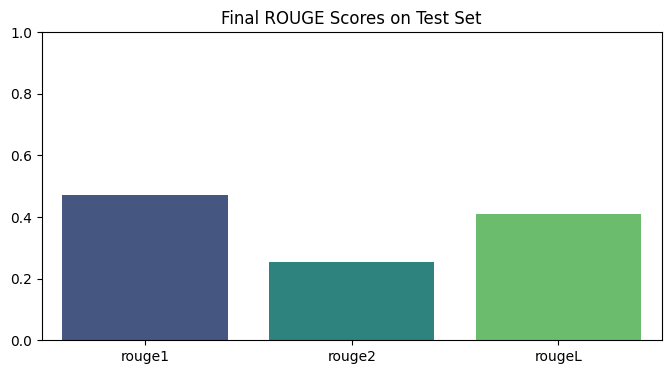

In [8]:
print("📊 Evaluating model on the test set...")
test_results = trainer.evaluate(eval_dataset=tokenized_datasets["test"])

# Display results in a readable format
df_results = pd.DataFrame([test_results])
print(df_results[['eval_rouge1', 'eval_rouge2', 'eval_rougeL', 'eval_loss']])

# Visualization: Compare metrics
plt.figure(figsize=(8, 4))
metrics = ['rouge1', 'rouge2', 'rougeL']
values = [test_results[f'eval_{m}'] for m in metrics]
sns.barplot(x=metrics, y=values, palette='viridis')
plt.title("Final ROUGE Scores on Test Set")
plt.ylim(0, 1) 
plt.show()

In [9]:
def generate_summary(text, model, tokenizer):
    # Prepare the text
    inputs = tokenizer(text, max_length=512, truncation=True, padding="max_length", return_tensors="pt").to(device)
    
    # Generate summary IDs
    summary_ids = model.generate(
        inputs["input_ids"], 
        num_beams=4, 
        max_length=60, 
        early_stopping=True
    )
    
    # Decode back to text
    return tokenizer.decode(summary_ids[0], skip_special_tokens=True)

# Pick a random example from the test set
sample_idx = 10 
raw_document = xsum['test'][sample_idx]['document']
actual_summary = xsum['test'][sample_idx]['summary']

# Generate our model's summary
generated_summary = generate_summary(raw_document, model, tokenizer)

print(f"{'='*30} TEST EXAMPLE {'='*30}")
print(f"Original Document (First 300 chars): {raw_document[:300]}...")
print(f"\n✅ Generated Summary: {generated_summary}")
print(f"Actual Summary: {actual_summary}")
print(f"{'='*75}")

============================== TEST EXAMPLE ==============================
Original Document (First 300 chars): The move is in response to an £8m cut in the subsidy received from the Department of Employment and Learning (DEL).
The cut in undergraduate places will come into effect from September 2015.
Job losses will be among both academic and non-academic staff and Queen's says no compulsory redundancies sho...

✅ Generated Summary: Queen's University in Belfast has announced plans to cut more than 1,000 student places over the next three years.
Actual Summary: Queen's University Belfast is cutting 236 jobs and 290 student places due to a funding reduction.


In [10]:
save_path = "./final_pegasus_model"
model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

print(f"Model saved to {save_path}. You can now use it for your graduation project or portfolio!")

Model saved to ./final_pegasus_model. You can now use it for your graduation project or portfolio!
